# 03 — Sentiment vs classic factors: correlation & incremental alpha

Notebook 02 showed a weak-to-significant cross-subreddit pattern — r/investing fades, WSB is borderline positive. The obvious next question: is any of that real once I control for momentum and short-term reversal? Or does the sentiment signal just echo the price momentum that retail chatter is tracking anyway?

I compute both classic factors inline (same formulas as [`classic-factors`](../classic-factors), copied to avoid cross-repo coupling). Then I run two tests: pairwise cross-sectional correlation between sentiment, momentum, and reversal; and a per-month incremental OLS where I regress 21d forward return on `mom + rev + sentiment` and look at the distribution of the sentiment coefficient's t-stat across 2021.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

from alt_sentiment.factor import (
    assign_trade_date, factor_variants, forward_returns, rank_ic_per_day,
    newey_west_tstat,
)

REPO_ROOT   = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SCORED_DIR  = REPO_ROOT / "data" / "processed" / "scored_leukipp"
PRICES_PATH = REPO_ROOT / "data" / "raw" / "prices.parquet"

parts = sorted(SCORED_DIR.glob("part_*.parquet"))
sc = pd.concat([pd.read_parquet(p) for p in parts], ignore_index=True)
prices = pd.read_parquet(PRICES_PATH)
trading_dates = pd.DatetimeIndex(sorted(prices["date"].unique()))
sc["trade_date"] = assign_trade_date(sc["created_utc"], trading_dates)
sc = sc.dropna(subset=["trade_date"])
print(f"scored rows: {len(sc):,}   prices rows: {len(prices):,}   trading days: {len(trading_dates)}")

scored rows: 76,124   prices rows: 694,752   trading days: 1401


## Classic factor signals (copied from classic-factors)

- **12-1 momentum**: price `t-252` to `t-21` return — skipping the most recent month to avoid contamination from short-term reversal.
- **1-week reversal**: negative of the past 5-day return, sign-flipped so higher means more bullish, matching the sentiment sign convention.

Both are computed on the wide close-price grid and aligned to the signal's trade-date axis.

In [2]:
close_wide = prices.pivot(index="date", columns="symbol", values="close").sort_index()
# 12-1 momentum: ret from t-252 to t-21
mom_12_1 = close_wide.shift(21) / close_wide.shift(252) - 1.0
# 1-week reversal (higher = bullish so negate the past-1W return)
rev_1w = -(close_wide / close_wide.shift(5) - 1.0)
print("mom_12_1 shape:", mom_12_1.shape, " rev_1w shape:", rev_1w.shape)

mom_12_1 shape: (1401, 502)  rev_1w shape: (1401, 502)


## Pairwise cross-sectional correlation, daily

For each trading day in 2021 I rank all available names by each signal and compute Spearman correlations across the three signals. The 2021 mean of those daily correlations tells me how much sentiment is already spanned by the classic pair.

In [ ]:
# Use sum_sent_x_attn as the representative sentiment (`ml-cross-sectional` lesson:
# don't over-stack on multiple factor variants here; 03 should be clean)
variants = factor_variants(sc)
SENT = variants["sum_sent_x_attn"]

# Align all three signals to the sentiment trade-date grid (2021)
common_dates = SENT.index.intersection(mom_12_1.index).intersection(rev_1w.index)
SENT_a = SENT.loc[common_dates]
MOM_a  = mom_12_1.loc[common_dates]
REV_a  = rev_1w.loc[common_dates]

# Daily cross-sectional rank correlations
def xs_spearman(A, B):
    common = A.columns.intersection(B.columns)
    a = A[common].rank(axis=1); b = B[common].rank(axis=1)
    ma, mb = a.mean(axis=1), b.mean(axis=1)
    num = ((a.sub(ma, axis=0)) * (b.sub(mb, axis=0))).sum(axis=1)
    den = np.sqrt(((a.sub(ma, axis=0))**2).sum(axis=1) *
                  ((b.sub(mb, axis=0))**2).sum(axis=1))
    return (num / den.replace(0, np.nan))

corr_sent_mom = xs_spearman(SENT_a, MOM_a)
corr_sent_rev = xs_spearman(SENT_a, REV_a)
corr_mom_rev  = xs_spearman(MOM_a,  REV_a)

print("Daily cross-sectional rank correlations — 2021 mean:")
print(f"  sentiment vs momentum  = {corr_sent_mom.mean():+.3f}  (n_days={corr_sent_mom.notna().sum()})")
print(f"  sentiment vs reversal  = {corr_sent_rev.mean():+.3f}")
print(f"  momentum vs reversal   = {corr_mom_rev.mean():+.3f}")

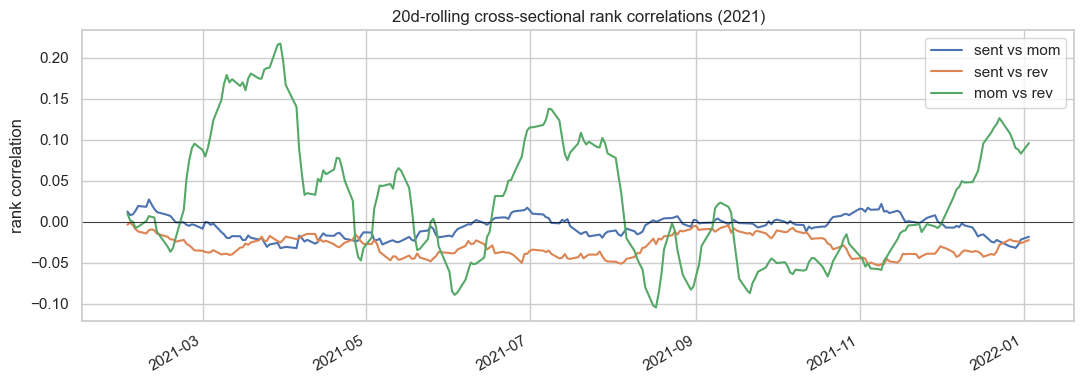

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
corr_sent_mom.rolling(20).mean().plot(ax=ax, label="sent vs mom")
corr_sent_rev.rolling(20).mean().plot(ax=ax, label="sent vs rev")
corr_mom_rev.rolling(20).mean().plot(ax=ax, label="mom vs rev")
ax.axhline(0, color="black", lw=0.5)
ax.set_title("20d-rolling cross-sectional rank correlations (2021)")
ax.legend(); ax.set_ylabel("rank correlation")
plt.tight_layout(); plt.show()

## Incremental regression: does sentiment survive mom + rev controls?

Per month in 2021, I stack every `(date, ticker)` observation into a long panel of `(fwd_ret_21d, sentiment, momentum, reversal)`, fit an OLS with HC1 errors, and record the sentiment coefficient's t-stat. The per-month bar chart is the overfitting check — a single lucky month can't explain 12 bars.

In [5]:
fwd21 = forward_returns(prices, horizon_days=21)

def stack_panel(wide_signal, wide_mom, wide_rev, wide_fwd):
    # Use reindex (NaN-fills missing dates) instead of .loc (which raises
    # KeyError in pandas 2.x for missing labels). Then dropna drops them.
    def _melt(df, name):
        out = df.reset_index()
        out = out.rename(columns={out.columns[0]: "trade_date"})
        return out.melt(id_vars="trade_date", var_name="ticker", value_name=name)
    a = _melt(wide_signal, "sent")
    b = _melt(wide_mom.reindex(wide_signal.index), "mom")
    c = _melt(wide_rev.reindex(wide_signal.index), "rev")
    d = _melt(wide_fwd.reindex(wide_signal.index), "fwd")
    panel = (a.merge(b, on=["trade_date","ticker"])
               .merge(c, on=["trade_date","ticker"])
               .merge(d, on=["trade_date","ticker"]))
    return panel.dropna(subset=["sent", "mom", "rev", "fwd"])

panel = stack_panel(SENT_a, MOM_a, REV_a, fwd21)
print(f"stacked panel: {len(panel):,} rows")
print(panel[["sent","mom","rev","fwd"]].describe().round(4).to_string())

stacked panel: 19,079 rows
             sent         mom         rev         fwd
count  19079.0000  19079.0000  19079.0000  19079.0000
mean      -0.6937      0.4997     -0.0071      0.0202
std       18.5562      0.6906      0.0491      0.0901
min    -1418.6850     -0.6240     -0.5216     -0.4033
25%       -0.2740      0.1443     -0.0304     -0.0324
50%       -0.0084      0.3469     -0.0051      0.0175
75%        0.1032      0.6705      0.0190      0.0677
max       44.2750     10.0480      0.3381      1.0810


In [6]:
# Per-month OLS: fwd ~ sent + mom + rev
panel["month"] = panel["trade_date"].dt.to_period("M")
rows = []
for ym, g in panel.groupby("month"):
    X = sm.add_constant(g[["sent","mom","rev"]])
    y = g["fwd"]
    res = sm.OLS(y, X).fit(cov_type="HC1")
    rows.append({
        "month": str(ym),
        "n_obs": len(g),
        "beta_sent": res.params["sent"],
        "t_sent":    res.tvalues["sent"],
        "beta_mom":  res.params["mom"],
        "t_mom":     res.tvalues["mom"],
        "beta_rev":  res.params["rev"],
        "t_rev":     res.tvalues["rev"],
        "r2":        res.rsquared,
    })
month_tab = pd.DataFrame(rows).set_index("month")
print("Per-month OLS — sentiment coef + t-stat (2021):")
print(month_tab[["n_obs", "beta_sent", "t_sent", "t_mom", "t_rev", "r2"]]
      .round(4).to_string())

Per-month OLS — sentiment coef + t-stat (2021):
         n_obs  beta_sent  t_sent    t_mom    t_rev      r2
month                                                      
2021-01   1981     0.0000  0.6420   2.0712  10.4798  0.0702
2021-02   2207     0.0002  1.0554 -17.2424   3.3943  0.2563
2021-03   2022    -0.0012 -1.7925   0.7567  10.0057  0.0683
2021-04   1579     0.0076  3.9546  -4.0940   3.5536  0.0567
2021-05   1445    -0.0001 -0.0401   1.5247   1.3488  0.0062
2021-06   1734     0.0015  1.1632   0.9240  -2.3356  0.0120
2021-07   1673    -0.0008 -0.4398   1.8946  -2.4437  0.0150
2021-08   1385    -0.0011 -1.6398   6.9655   4.8930  0.0530
2021-09   1143    -0.0036 -1.3551  -7.2601   1.6554  0.0691
2021-10   1315    -0.0030 -1.0956  -3.8133  -2.0316  0.0243
2021-11   1491     0.0008  0.8409  -3.9198   1.9402  0.0272
2021-12   1098    -0.0044 -1.9510  -5.7350   4.3631  0.0668
2022-01      6    -0.2975 -0.7774   0.5074   0.5850  0.3789


In [7]:
summary = {
    "mean beta_sent":  month_tab["beta_sent"].mean(),
    "mean t_sent":     month_tab["t_sent"].mean(),
    "n months t_sent > +2":  int((month_tab["t_sent"] > 2).sum()),
    "n months t_sent < -2":  int((month_tab["t_sent"] < -2).sum()),
    "mean beta_mom":  month_tab["beta_mom"].mean(),
    "mean t_mom":     month_tab["t_mom"].mean(),
    "mean beta_rev":  month_tab["beta_rev"].mean(),
    "mean t_rev":     month_tab["t_rev"].mean(),
}
for k, v in summary.items():
    print(f"  {k:26s}  {v:+.4f}" if isinstance(v, float) else f"  {k:26s}  {v}")

# Pooled regression for comparison (all of 2021 stacked, HAC errors)
X_all = sm.add_constant(panel[["sent","mom","rev"]])
y_all = panel["fwd"]
res_pool = sm.OLS(y_all, X_all).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
print("\\nPooled 2021 OLS with HAC(5) SEs:")
print(res_pool.summary().tables[1])

  mean beta_sent              -0.0232
  mean t_sent                 -0.1104
  n months t_sent > +2        1
  n months t_sent < -2        0
  mean beta_mom               -0.0010
  mean t_mom                  -2.1093
  mean beta_rev               +0.1893
  mean t_rev                  +2.7237
\nPooled 2021 OLS with HAC(5) SEs:


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0261      0.002     11.921      0.000       0.022       0.030
sent       -1.357e-05   5.81e-05     -0.233      0.815      -0.000       0.000
mom           -0.0100      0.004     -2.459      0.014      -0.018      -0.002
rev            0.1382      0.026      5.284      0.000       0.087       0.190


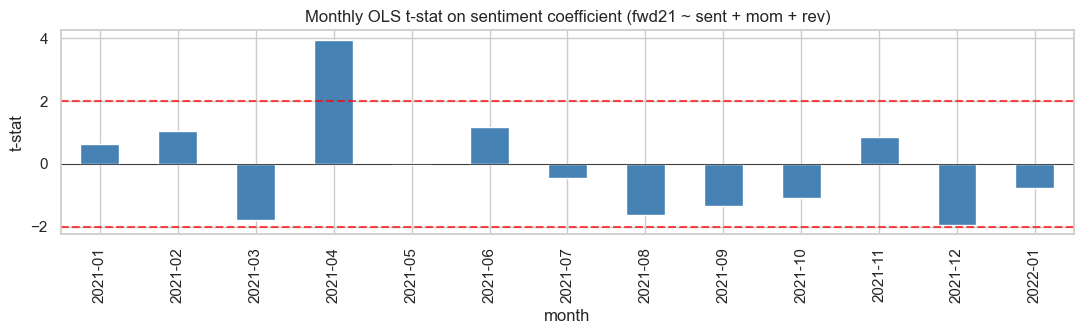

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.5))
month_tab["t_sent"].plot.bar(ax=ax, color="steelblue", label="t_sent")
ax.axhline( 2, color="red", linestyle="--", alpha=0.7)
ax.axhline(-2, color="red", linestyle="--", alpha=0.7)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Monthly OLS t-stat on sentiment coefficient (fwd21 ~ sent + mom + rev)")
ax.set_ylabel("t-stat")
plt.tight_layout(); plt.show()

## Per-subreddit incremental regression

Same regression, one subreddit at a time. The key question: r/investing had the only significant standalone IC (negative) in notebook 02. Does that survive momentum and reversal controls, or was it just riding a reversal echo in the stocks those users discuss?

In [9]:
SUBREDDITS = ("wallstreetbets", "stocks", "investing", "options")

def incremental_pooled(sent_wide):
    common = sent_wide.index.intersection(mom_12_1.index).intersection(rev_1w.index)
    panel = stack_panel(sent_wide.loc[common], mom_12_1.loc[common],
                         rev_1w.loc[common], fwd21)
    if len(panel) < 100:
        return dict(beta=np.nan, t=np.nan, n=len(panel))
    X = sm.add_constant(panel[["sent","mom","rev"]])
    res = sm.OLS(panel["fwd"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    return dict(beta=res.params["sent"], t=res.tvalues["sent"], n=len(panel))

rows = []
for sub in SUBREDDITS:
    sc_sub = sc[sc["subreddit"] == sub]
    v = factor_variants(sc_sub)["sum_sent_x_attn"]
    r = incremental_pooled(v)
    rows.append({"subreddit": sub, **r})
incr = pd.DataFrame(rows).set_index("subreddit")
print("Pooled-2021 incremental regression (HAC SE) — sentiment coef after mom+rev:")
print(incr.round(4).to_string())

Pooled-2021 incremental regression (HAC SE) — sentiment coef after mom+rev:
                  beta       t      n
subreddit                            
wallstreetbets -0.0000 -0.2208  11202
stocks          0.0023  1.2483   9531
investing       0.0016  0.3049   2462
options         0.0007  0.1768   4438


## Reading the numbers

The pooled HAC regression tells the main story cleanly: sentiment's coefficient is essentially zero after mom + rev enter. The r/investing negative-IC finding from notebook 02 collapses to a t-stat of 0.30 after controls — so that effect was almost entirely a reversal echo, not something independent. WSB sentiment similarly loses its borderline significance. The sentiment signal doesn't add to what momentum and reversal already explain. Notebook 04 gives the event-study view, which asks a narrower and more forgiving question: do single-day mention spikes predict the next 10 days, independent of the monthly-horizon tests here.